<a href="https://colab.research.google.com/github/adarshabhattacharjee/comp_neuro_NMA/blob/main/W1D3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classifiers and regularizers


In [1]:
# @title Install and import feedback gadget

!pip3 install vibecheck datatops --quiet

from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",  # No text prompt
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_cn",
            "user_key": "y1x3mpx5",
        },
    ).render()


feedback_prefix = "W1D3_T2"

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.1 MB/s eta 0:00:00


In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [3]:
# @title Figure settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [4]:
# @title Plotting Functions

def plot_weights(models, sharey=True):
  """Draw a stem plot of weights for each model in models dict."""
  n = len(models)
  f = plt.figure(figsize=(10, 2.5 * n))
  axs = f.subplots(n, sharex=True, sharey=sharey)
  axs = np.atleast_1d(axs)

  for ax, (title, model) in zip(axs, models.items()):

    ax.margins(x=.02)
    stem = ax.stem(model.coef_.squeeze())
    stem[0].set_marker(".")
    stem[0].set_color(".2")
    stem[1].set_linewidths(.5)
    stem[1].set_color(".2")
    stem[2].set_visible(False)
    ax.axhline(0, color="C3", lw=3)
    ax.set(ylabel="Weight", title=title)
  ax.set(xlabel="Neuron (a.k.a. feature)")
  f.tight_layout()
  plt.show()


def plot_function(f, name, var, points=(-10, 10)):
    """Evaluate f() on linear space between points and plot.

    Args:
      f (callable): function that maps scalar -> scalar
      name (string): Function name for axis labels
      var (string): Variable name for axis labels.
      points (tuple): Args for np.linspace to create eval grid.
    """
    x = np.linspace(*points)
    ax = plt.figure().subplots()
    ax.plot(x, f(x))
    ax.set(
      xlabel=f'${var}$',
      ylabel=f'${name}({var})$'
    )
    plt.show()


def plot_model_selection(C_values, accuracies):
  """Plot the accuracy curve over log-spaced C values."""
  ax = plt.figure().subplots()
  ax.set_xscale("log")
  ax.plot(C_values, accuracies, marker="o")
  best_C = C_values[np.argmax(accuracies)]
  ax.set(
      xticks=C_values,
      xlabel="C",
      ylabel="Cross-validated accuracy",
      title=f"Best C: {best_C:1g} ({np.max(accuracies):.2%})",
  )
  plt.show()


def plot_non_zero_coefs(C_values, non_zero_l1, n_voxels):
  """Plot the accuracy curve over log-spaced C values."""
  ax = plt.figure().subplots()
  ax.set_xscale("log")
  ax.plot(C_values, non_zero_l1, marker="o")
  ax.set(
    xticks=C_values,
    xlabel="C",
    ylabel="Number of non-zero coefficients",
  )
  ax.axhline(n_voxels, color=".1", linestyle=":")
  ax.annotate("Total\n# Neurons", (C_values[0], n_voxels * .98), va="top")
  plt.show()

In [5]:
#@title Data retrieval and loading
import os
import requests
import hashlib

url = "https://osf.io/r9gh8/download"
fname = "W1D4_steinmetz_data.npz"
expected_md5 = "d19716354fed0981267456b80db07ea8"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    elif hashlib.md5(r.content).hexdigest() != expected_md5:
      print("!!! Data download appears corrupted !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

def load_steinmetz_data(data_fname=fname):

  with np.load(data_fname) as dobj:
    data = dict(**dobj)

  return data

---
##Logistic regression

Logistic Regression is a binary classification model. It is a GLM with a *logistic* link function and a *Bernoulli* (i.e. coinflip) noise model.

Like in the last notebook, logistic regression invokes a standard procedure:

1.   Define a *model* of how inputs relate to outputs.
2.   Adjust the parameters to maximize (log) probability of your data given your model

The fundamental input/output equation of logistic regression is:

\begin{equation}
\hat{y} \equiv p(y=1|x,\theta) = \sigma(\theta^\top x)
\end{equation}

Note that we interpret the output of logistic regression, $\hat{y}$, as the **probability that y = 1** given inputs $x$ and parameters $\theta$.

Here $\sigma(\cdot)$ is a "squashing" function called the **sigmoid function** or **logistic function**. Its output is in the range $0 \leq y \leq 1$. It looks like this:

\begin{equation}
\sigma(z) = \frac{1}{1 + \textrm{exp}(-z)}
\end{equation}

Recall that $z = \theta^\top x$. The parameters decide whether $\theta^\top x$ will be very negative, in which case $\sigma(\theta^\top x)\approx 0$, or very positive, meaning  $\sigma(\theta^\top x)\approx 1$.
</details>

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9025/31098105.py:14: SyntaxWarning: invalid escape sequence '\s'
  plot_function(sigmoid, "\sigma", "z", (-10, 10))


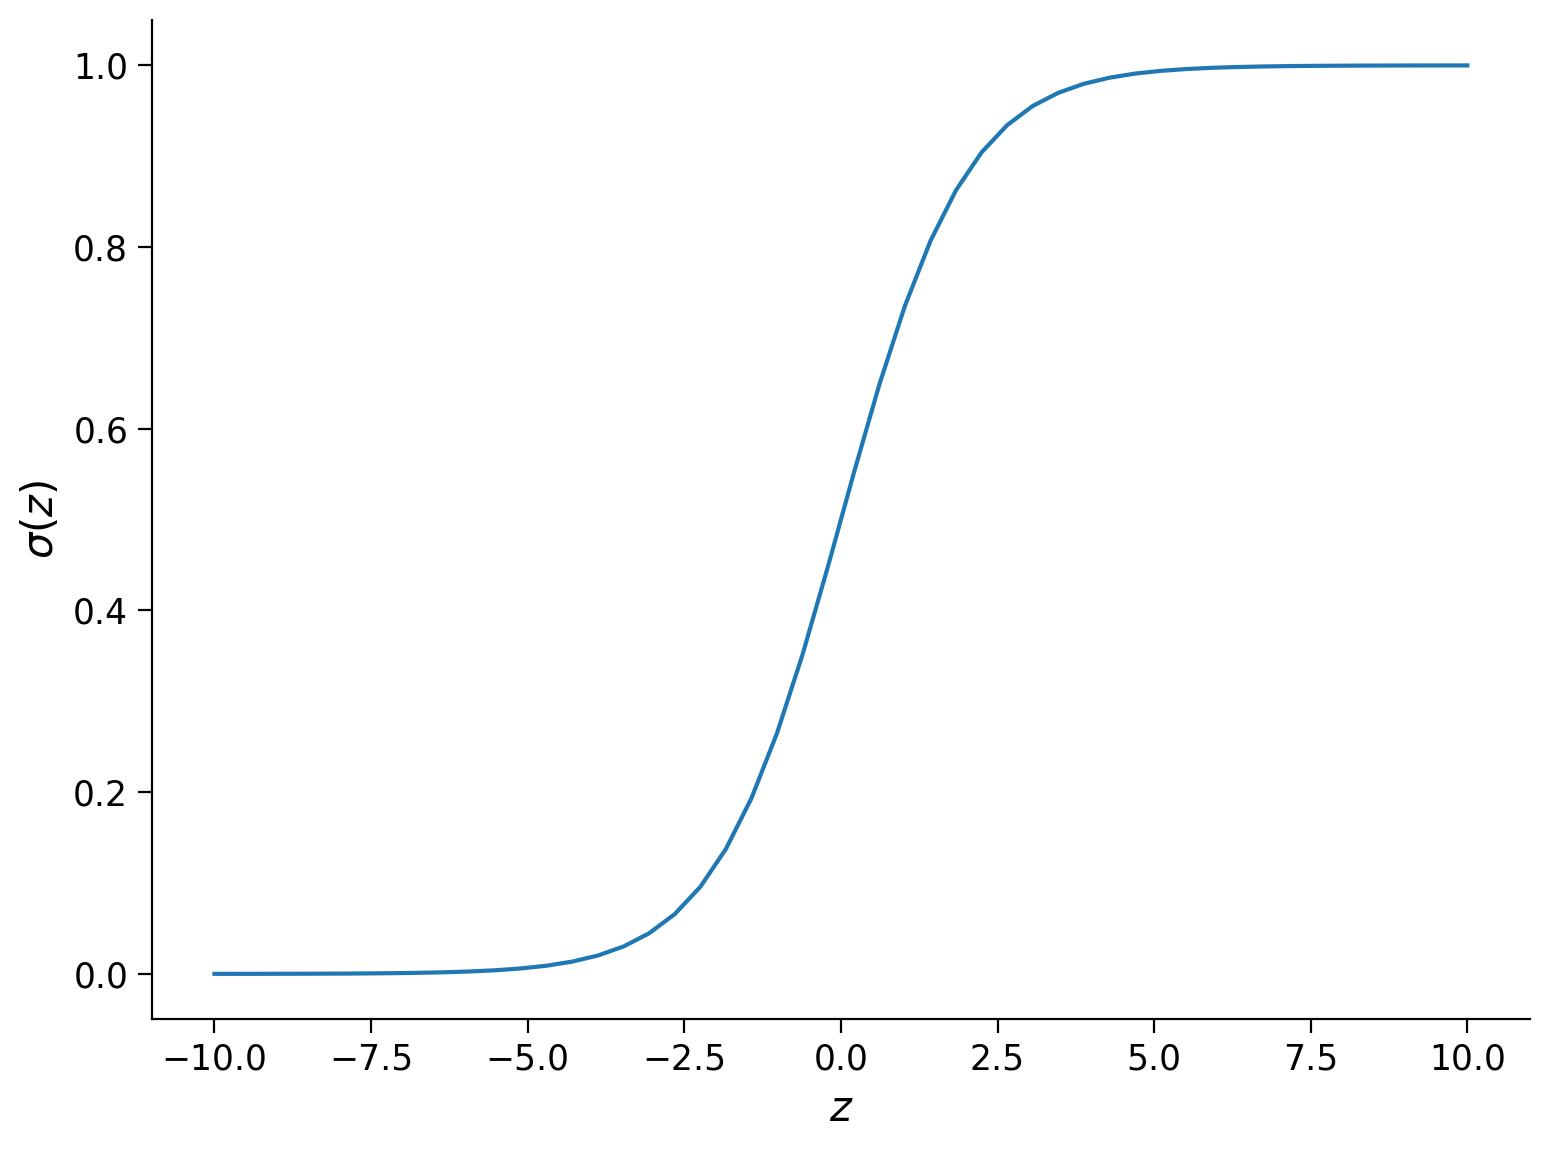

In [6]:
def sigmoid(z):
  """Return the logistic transform of z."""
  ##############################################################################
  # TODO for students: Fill in the missing code (...) and remove the error
  #raise NotImplementedError("Student exercise: implement the sigmoid function")
  ##############################################################################

  sigmoid = 1/(1 + np.exp(-z))

  return sigmoid


# Visualize
plot_function(sigmoid, "\sigma", "z", (-10, 10))

---
## Decoding neural data with logistic regression


In this notebook we'll use the Steinmetz dataset that you have seen previously. Recall that this dataset includes recordings of neurons as mice perform a decision task.

Mice had the task of turning a wheel to indicate whether they perceived a Gabor stimulus to the left, to the right, or not at all. Neuropixel probes measured spikes across the cortex. Check out the following task schematic below from the BiorXiv preprint.




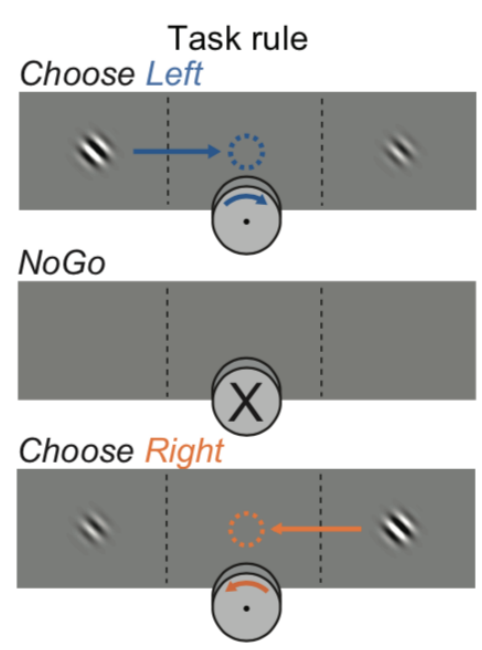

In [7]:
# @markdown Execute to see schematic
import IPython
IPython.display.Image("http://kordinglab.com/images/others/steinmetz-task.png")

Today we're going to **decode the decision from neural data** using Logistic Regression. We will only consider trials where the mouse chose "Left" or "Right" and ignore NoGo trials.

### Data format

In the hidden `Data retrieval and loading` cell, there is a function that loads the data:

- `spikes`: an array of normalized spike rates with shape `(n_trials, n_neurons)`
- `choices`: a vector of 0s and 1s, indicating the animal's behavioural response, with length `n_trials`.

In [8]:
data = load_steinmetz_data()
for key, val in data.items():
  print(key, val.shape)

spikes (276, 691)
choices (276,)


As with the GLMs you've seen in the previous tutorial (Linear and Poisson Regression), we will need two data structures:

- an `X` matrix with shape `(n_samples, n_features)`
- a `y` vector with length `n_samples`.

In the previous notebook, `y` corresponded to the neural data, and `X` corresponded to something about the experiment. Here, we are going to invert those relationships. That's what makes this a *decoding* model: we are going to predict behaviour (`y`) from the neural responses (`X`):

In [9]:
y = data["choices"]
X = data["spikes"]

In [10]:
# Define the model
log_reg = LogisticRegression(penalty=None)

# Fit it to data
log_reg.fit(X, y)

LogisticRegression(penalty=None)

There's two steps here:

- We *initialized* the model with a hyperparameter, telling it what penalty to use (we'll focus on this in the second part of the notebook)
- We *fit* the model by passing it the `X` and `y` objects.



In [11]:
y_pred = log_reg.predict(X)

In [12]:
def compute_accuracy(X, y, model):
  """Compute accuracy of classifier predictions.

  Args:
    X (2D array): Data matrix
    y (1D array): Label vector
    model (sklearn estimator): Classifier with trained weights.

  Returns:
    accuracy (float): Proportion of correct predictions.
  """
  #############################################################################
  # TODO Complete the function, then remove the next line to test it
  #raise NotImplementedError("Implement the compute_accuracy function")
  #############################################################################

  y_pred = model.predict(X)

  accuracy = np.mean(y_pred == y)

  return accuracy


# Compute train accuracy
train_accuracy = compute_accuracy(X, y, log_reg)
print(f"Accuracy on the training data: {train_accuracy:.2%}")

Accuracy on the training data: 100.00%


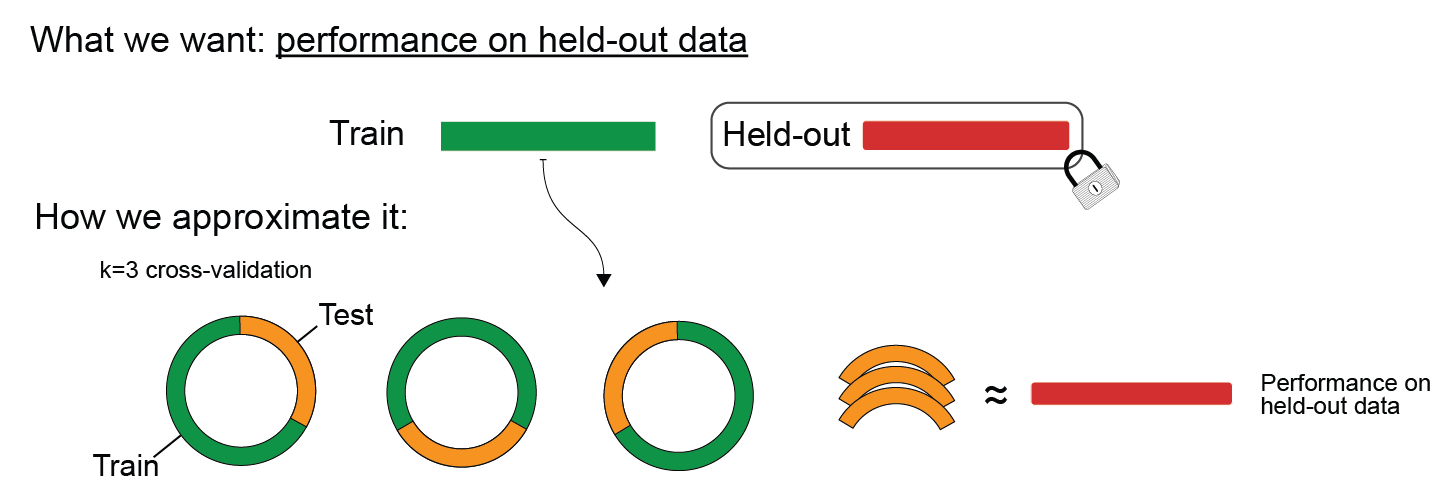

In [13]:
# @markdown Execute to see schematic
import IPython
IPython.display.Image("http://kordinglab.com/images/others/justCV-01.png")

### Cross-validating using `scikit-learn` helper functions

Yesterday, we asked you to write your own functions for implementing cross-validation. In practice, this won't be necessary, because `scikit-learn` offers a number of [helpful functions](https://scikit-learn.org/stable/model_selection.html) that will do this for you. For example, you can cross-validate a classifier using `cross_val_score`.

`cross_val_score` takes a `sklearn` model like `LogisticRegression`, as well as your `X` and `y` data. It then retrains your model on test/train splits of `X` and `y`, and returns the test accuracy on each of the test sets.

In [14]:
accuracies = cross_val_score(LogisticRegression(penalty=None), X, y, cv=8)  # k=8 cross validation

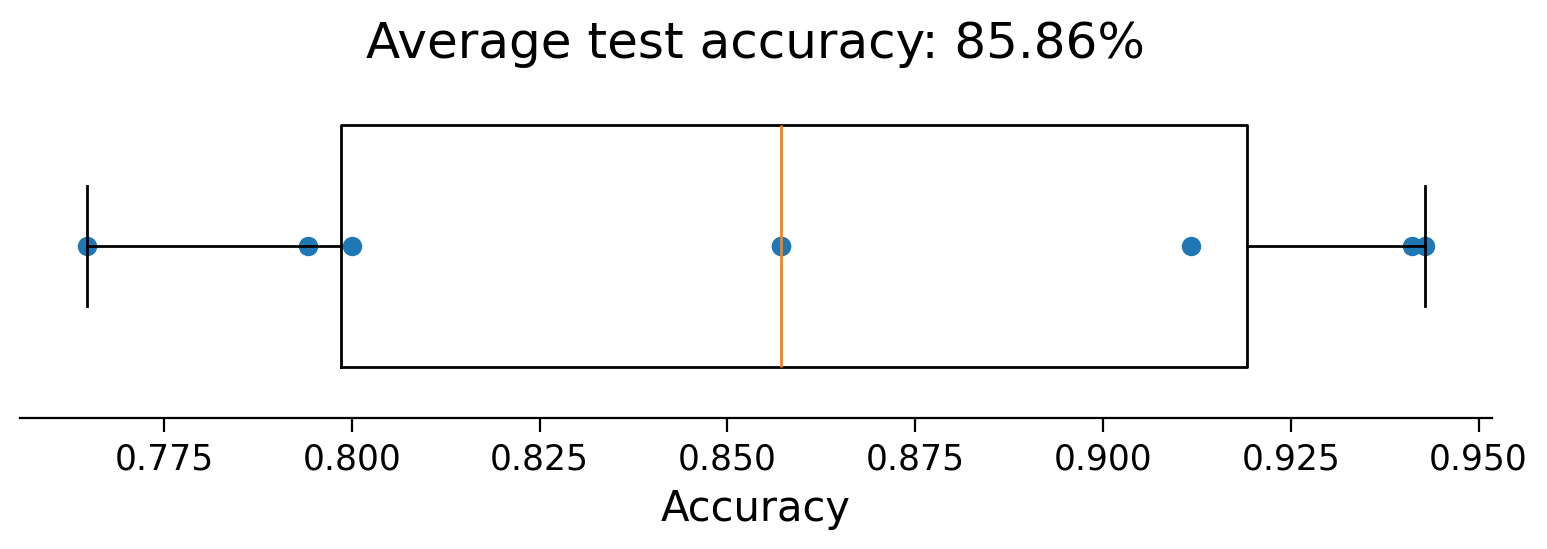

In [15]:
# @markdown Run to plot out these `k=8` accuracy scores.
f, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(accuracies, vert=False, widths=.7)
ax.scatter(accuracies, np.ones(8))
ax.set(
  xlabel="Accuracy",
  yticks=[],
  title=f"Average test accuracy: {accuracies.mean():.2%}"
)
ax.spines["left"].set_visible(False)
plt.show()

The lower cross-validated accuracy compared to the training accuracy (100%) suggests that the model is being *overfit*. Is this surprising? Think about the shape of the $X$ matrix:

In [16]:
print(X.shape)

(276, 691)


### Why more features than samples leads to overfitting

In brief, the variance of model estimation increases when there are more features than samples. That is, you would get a very different model every time you get new data and run `.fit()`. This is very related to the *bias/variance tradeoff* you learned about on day 1.

Why does this happen? Here's a tiny example to get your intuition going. Imagine trying to find a best-fit line in 2D when you only have 1 datapoint. There are simply an infinite number of lines that pass through that point. This is the situation we find ourselves in with more features than samples.

### What we can do about it
As you learned on day 1, you can decrease model variance if you don't mind increasing its bias. Here, we will increase bias by assuming that the correct parameters are all small. In our 2D example, this is like preferring the horizontal line to all others. This is one example of *regularization*.

-----

##Regularization




Regularization forces a model to learn a set solutions you *a priori* believe to be more correct, which reduces overfitting because it doesn't have as much flexibility to fit idiosyncrasies in the training data. This adds model bias, but it's a good bias because you know (maybe) that parameters should be small or mostly 0.

In a GLM, a common form of regularization is to *shrink* the classifier weights. In a linear model, you can see its effect by plotting the weights. We've defined a helper function, `plot_weights`, that we'll use extensively in this section.

</details>

Here is what the weights look like for a Logistic Regression model with no regularization:

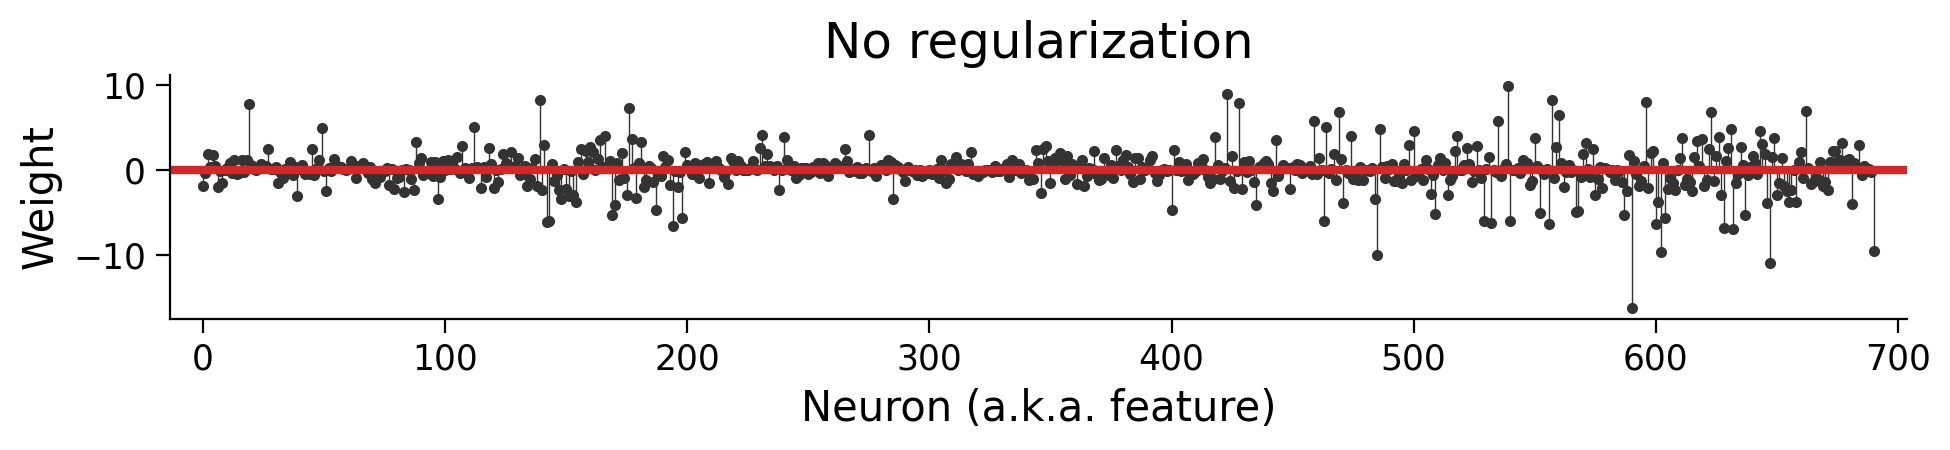

In [17]:
log_reg = LogisticRegression(penalty=None).fit(X, y)
plot_weights({"No regularization": log_reg})

It's important to understand this plot. Each dot visualizes a value in our parameter vector $\theta$. (It's the same style of plot as the one showing $\theta$ in the video). Since each feature is the time-averaged response of a neuron, each dot shows how the model uses each neuron to estimate a decision.

Note the scale of the y-axis. Some neurons have values of about $20$, whereas others scale to $-20$.

###$L_2$ regularization

Regularization comes in different flavors. A very common one uses an $L_2$ or "ridge" penalty. This changes the objective function to

\begin{equation}
-\log\mathcal{L}'(\theta | X, y)= -\log\mathcal{L}(\theta | X, y) +\frac\beta2\sum_i\theta_i^2,
\end{equation}

where $\beta$ is a *hyperparameter* that sets the *strength* of the regularization.

You can use regularization in `scikit-learn` by changing the `penalty`, and you can set the strength of the regularization with the `C` hyperparameter ($C = \frac{1}{\beta}$, so this sets the *inverse* regularization).

Let's compare the unregularized classifier weights with the classifier weights when we use the default `C = 1`:

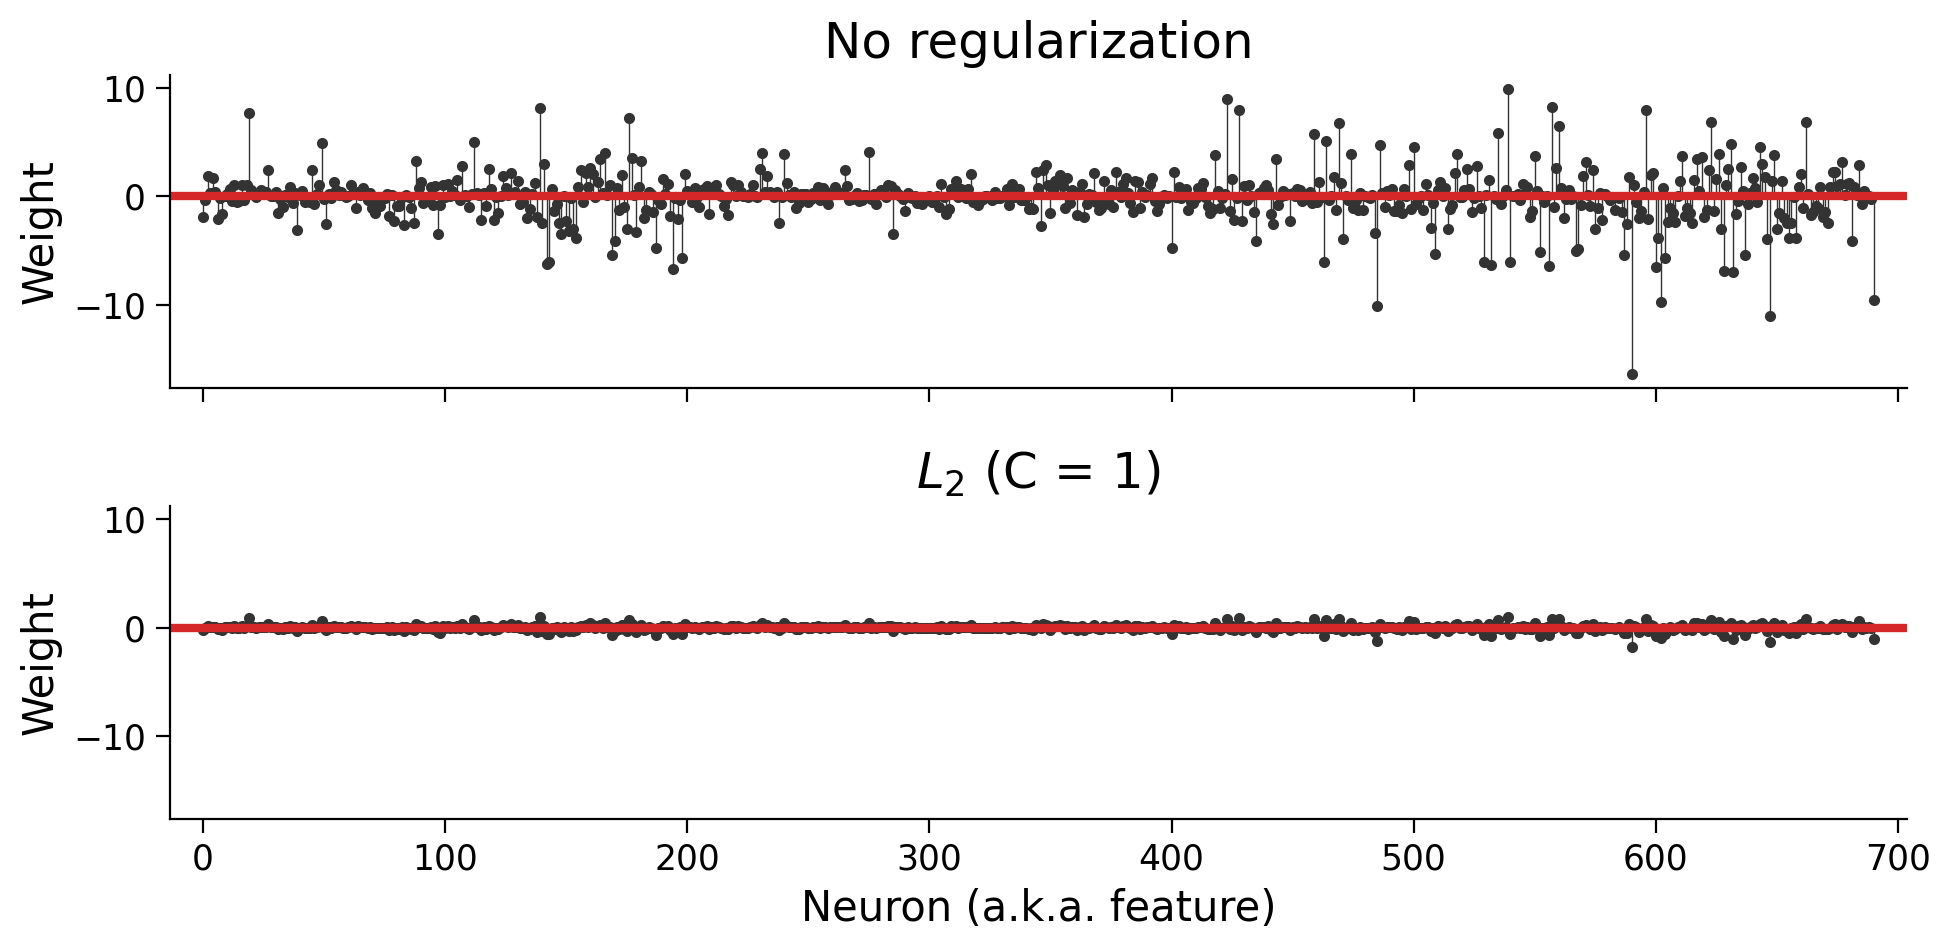

In [18]:
log_reg_l2 = LogisticRegression(penalty="l2", C=1).fit(X, y)

# now show the two models
models = {
  "No regularization": log_reg,
  "$L_2$ (C = 1)": log_reg_l2,
}
plot_weights(models)

Using the same scale for the two y axes, it's almost impossible to see the $L_2$ weights. Let's allow the y axis scales to adjust to each set of weights:

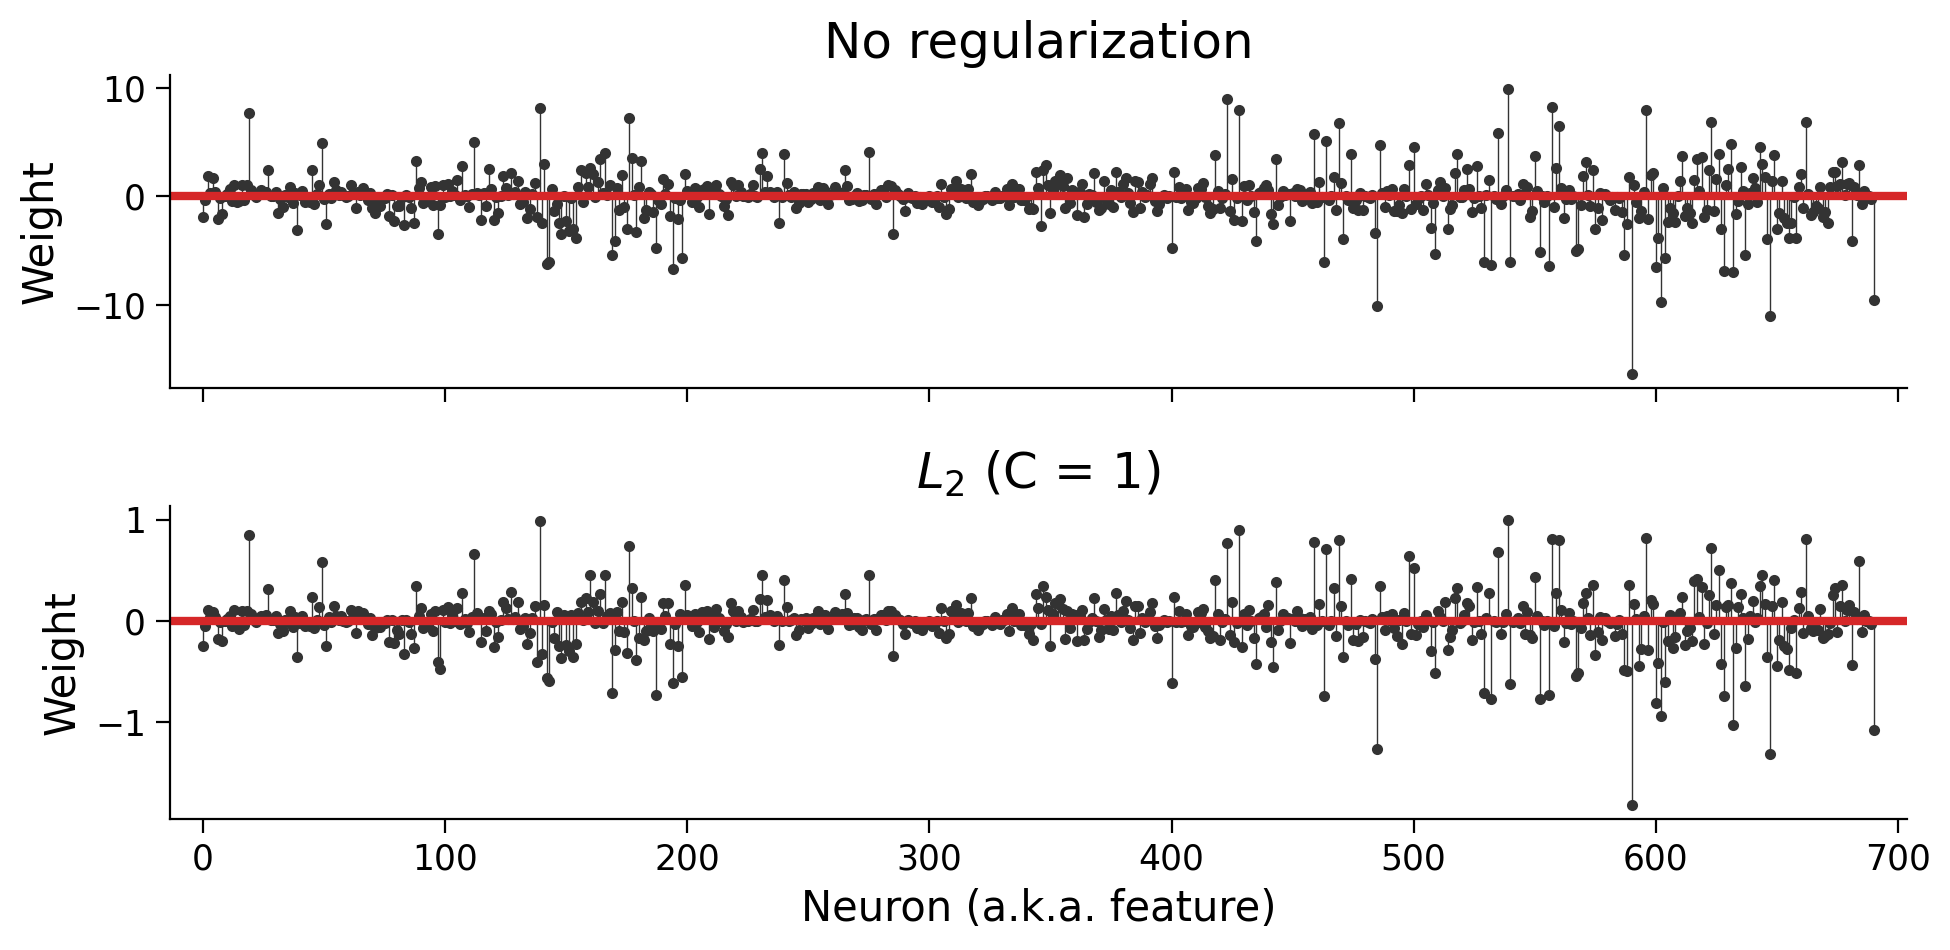

In [19]:
plot_weights(models, sharey=False)

In [20]:
# @markdown Execute this cell to enable the widget!

# Precompute the models so the widget is responsive
log_C_steps = 1, 11, 1
penalized_models = {}
for log_C in np.arange(*log_C_steps, dtype=int):
  m = LogisticRegression("l2", C=10 ** log_C, max_iter=5000)
  penalized_models[log_C] = m.fit(X, y)

@widgets.interact
def plot_observed(log_C = widgets.IntSlider(value=1, min=1, max=10, step=1)):
  models = {
    "No regularization": log_reg,
    f"$L_2$ (C = $10^{{{log_C}}}$)": penalized_models[log_C]
  }
  plot_weights(models)

interactive(children=(IntSlider(value=1, description='log_C', max=10, min=1), Output()), _dom_classes=('widget…

Recall from above that $C=\frac1\beta$ so larger $C$ is less regularization. The top panel corresponds to $C \rightarrow \infty$.

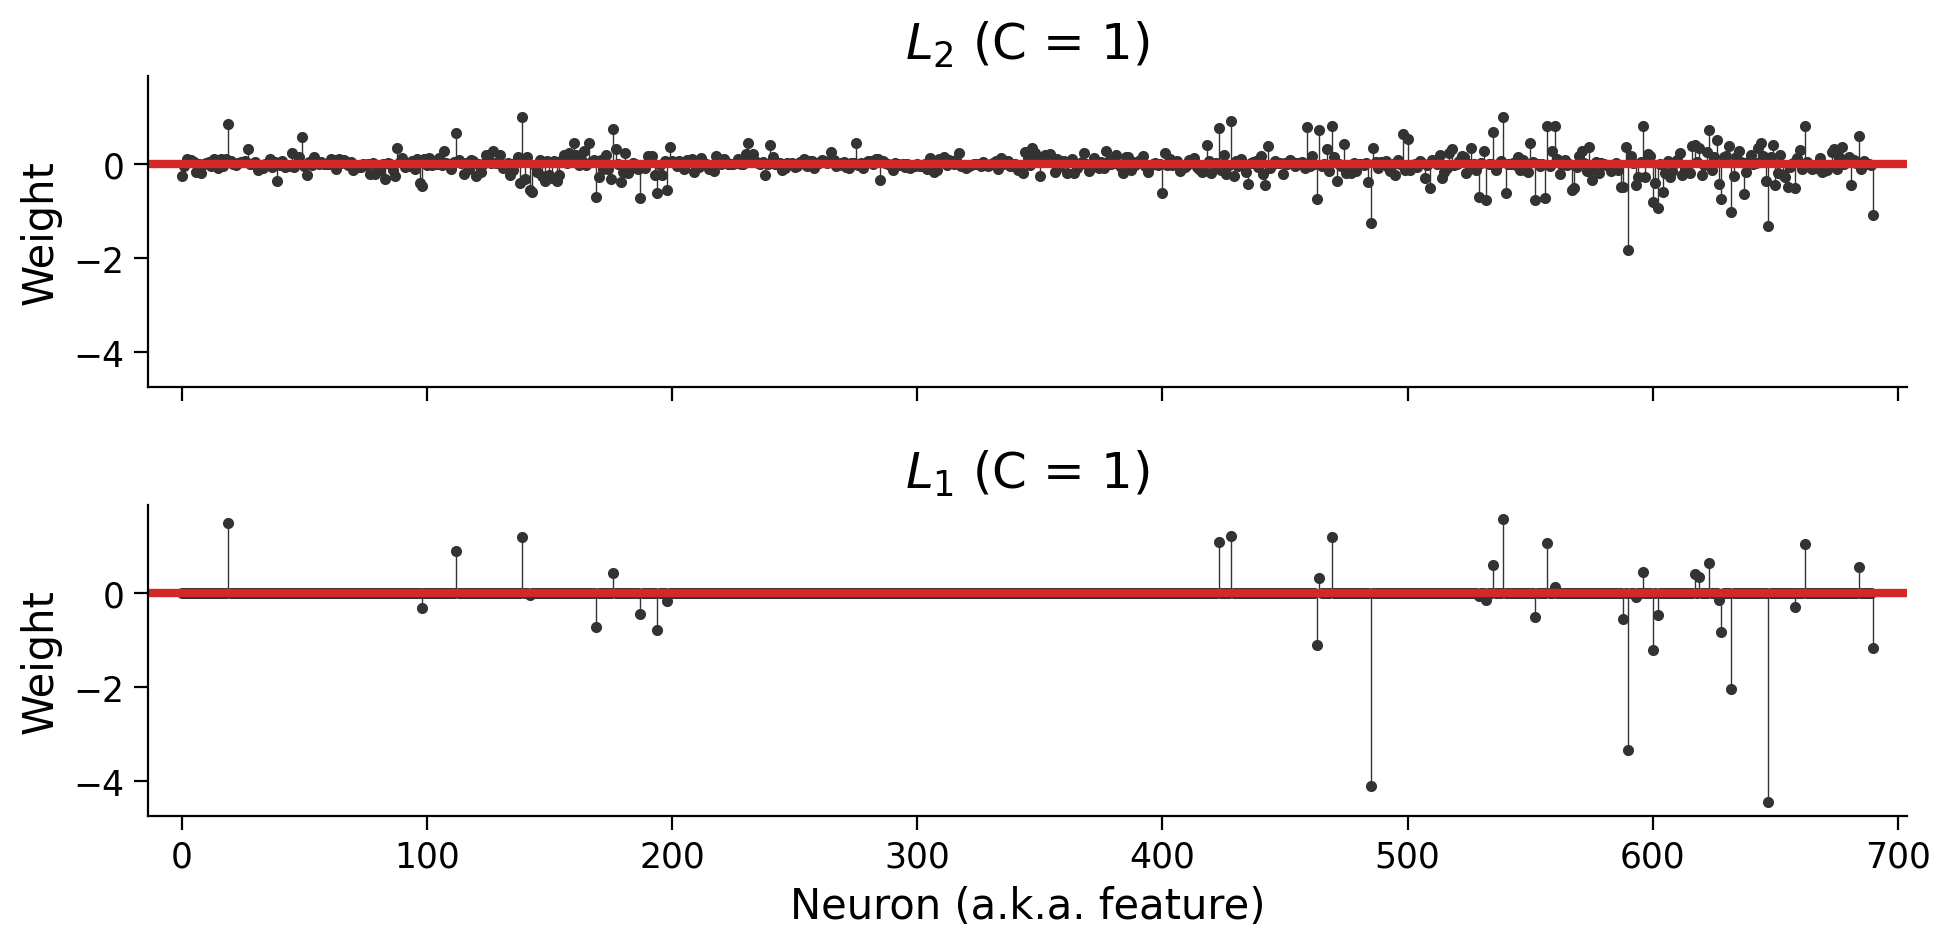

In [21]:
log_reg_l1 = LogisticRegression(penalty="l1", C=1, solver="saga", max_iter=5000)
log_reg_l1.fit(X, y)
models = {
  "$L_2$ (C = 1)": log_reg_l2,
  "$L_1$ (C = 1)": log_reg_l1,
}
plot_weights(models)

$L₂ (Ridge)$ spreads the importance across many features by shrinking all weights toward zero, but almost never to exactly zero.

Pros
1. Uses information from every feature.
2. Works well when many features each carry a little information.
3. More stable if features are correlated.

Cons
. Doesn't remove unnecessary features.

$L₁ (Lasso)$ encourages sparsity: it drives many weights to exactly zero, effectively selecting only a small subset of the most informative neurons.


Pros

1. Automatically performs feature selection.
2. Easier to interpret.
3. Faster prediction because many weights are zero.

Cons

If several features contain similar information, it may keep one and discard the others, even though they are all useful.


Note: You'll notice that we added two additional parameters: `solver="saga"` and `max_iter=5000`. The `LogisticRegression` class can use several different optimization algorithms ("solvers"), and not all of them support the $L_1$ penalty. At a certain point, the solver will give up if it hasn't found a minimum value. The `max_iter` parameter tells it to make more attempts; otherwise, we'd see an ugly warning about "convergence".

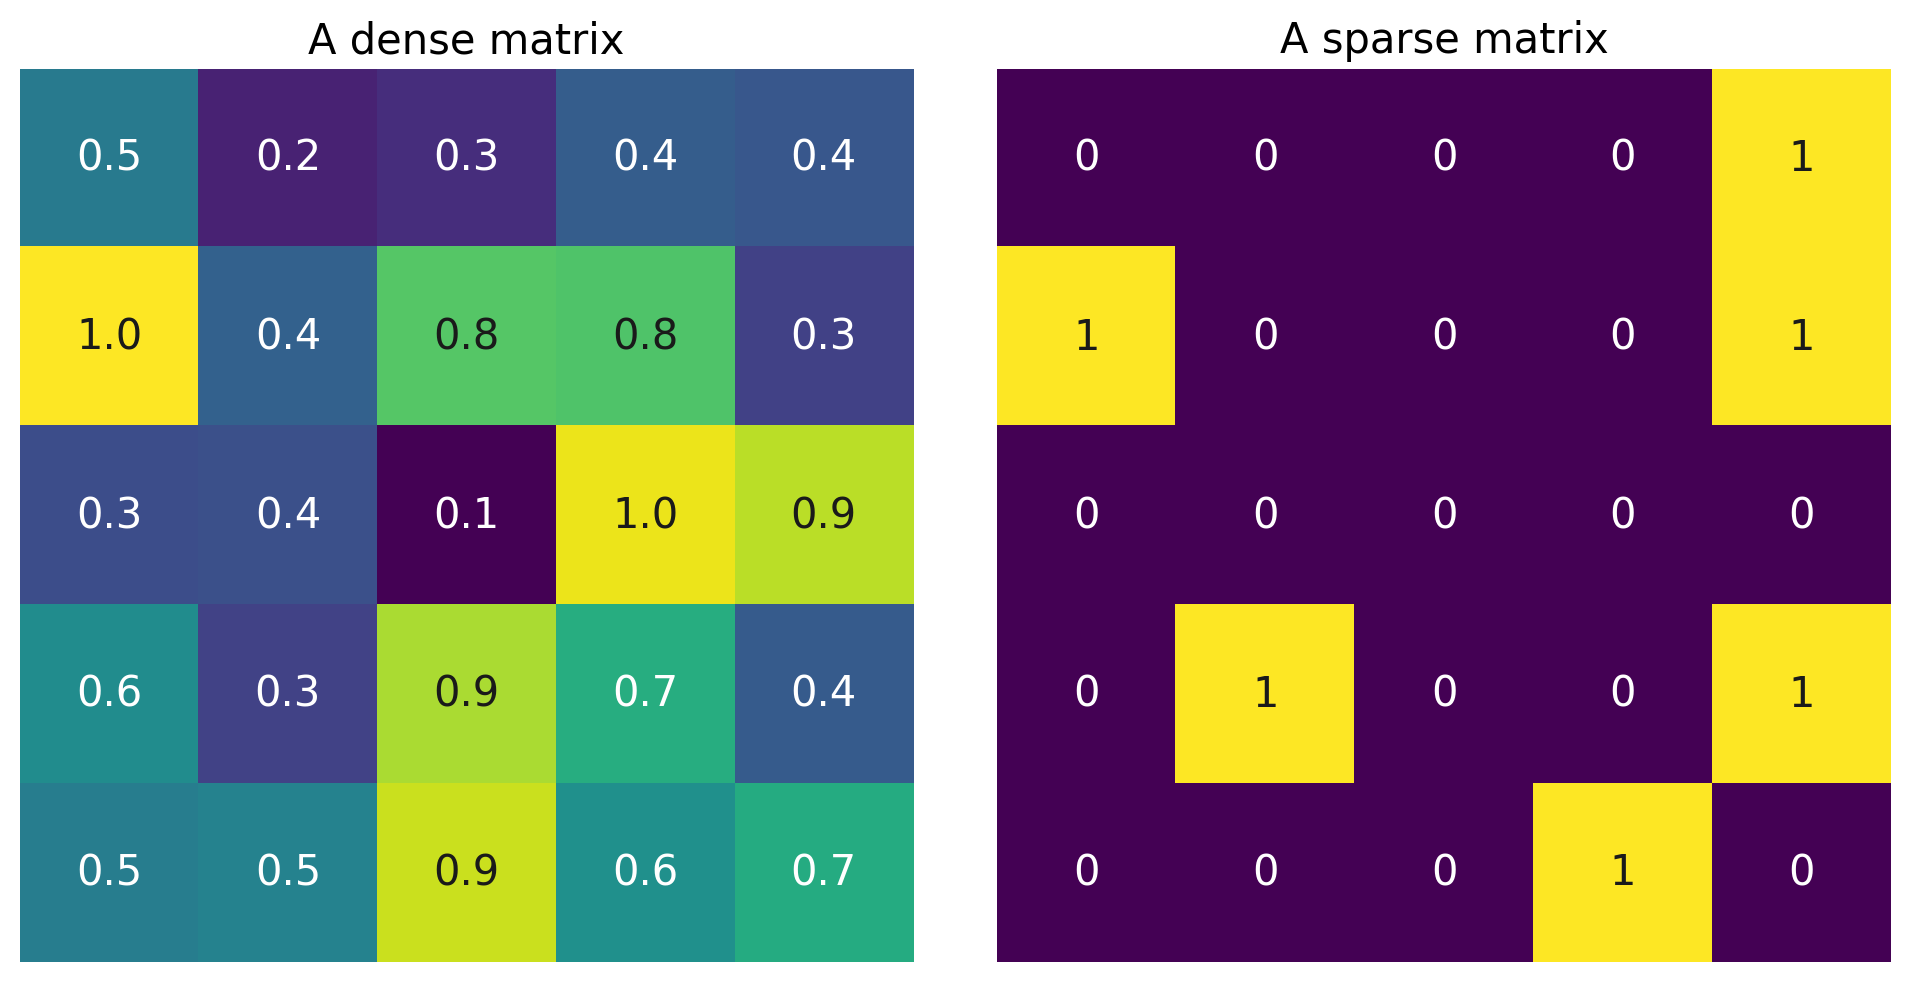

In [22]:
# @markdown Execute to plot a dense and a sparse matrix
np.random.seed(50)
n = 5
M = np.random.random((n, n))
M_sparse = np.random.choice([0, 1], size=(n, n), p=[0.8, 0.2])

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 5))

axs[0].imshow(M)
axs[1].imshow(M_sparse)
axs[0].axis('off')
axs[1].axis('off')
axs[0].set_title("A dense matrix", fontsize=15)
axs[1].set_title("A sparse matrix", fontsize=15)
text_kws = dict(ha="center", va="center")
for i in range(n):
  for j in range(n):
    iter_parts = axs, [M, M_sparse], ["{:.1f}", "{:d}"]
    for ax, mat, fmt in zip(*iter_parts):
      val = mat[i, j]
      color = ".1" if val > .7 else "w"
      ax.text(j, i, fmt.format(val), c=color, **text_kws)
plt.show()

### Coding Exercise 3.3: The effect of $L_1$ regularization on parameter sparsity

Please complete the following function to fit a regularized `LogisticRegression` model and return **the number of coefficients in the parameter vector that are equal to 0**.

Don't forget to check out the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).


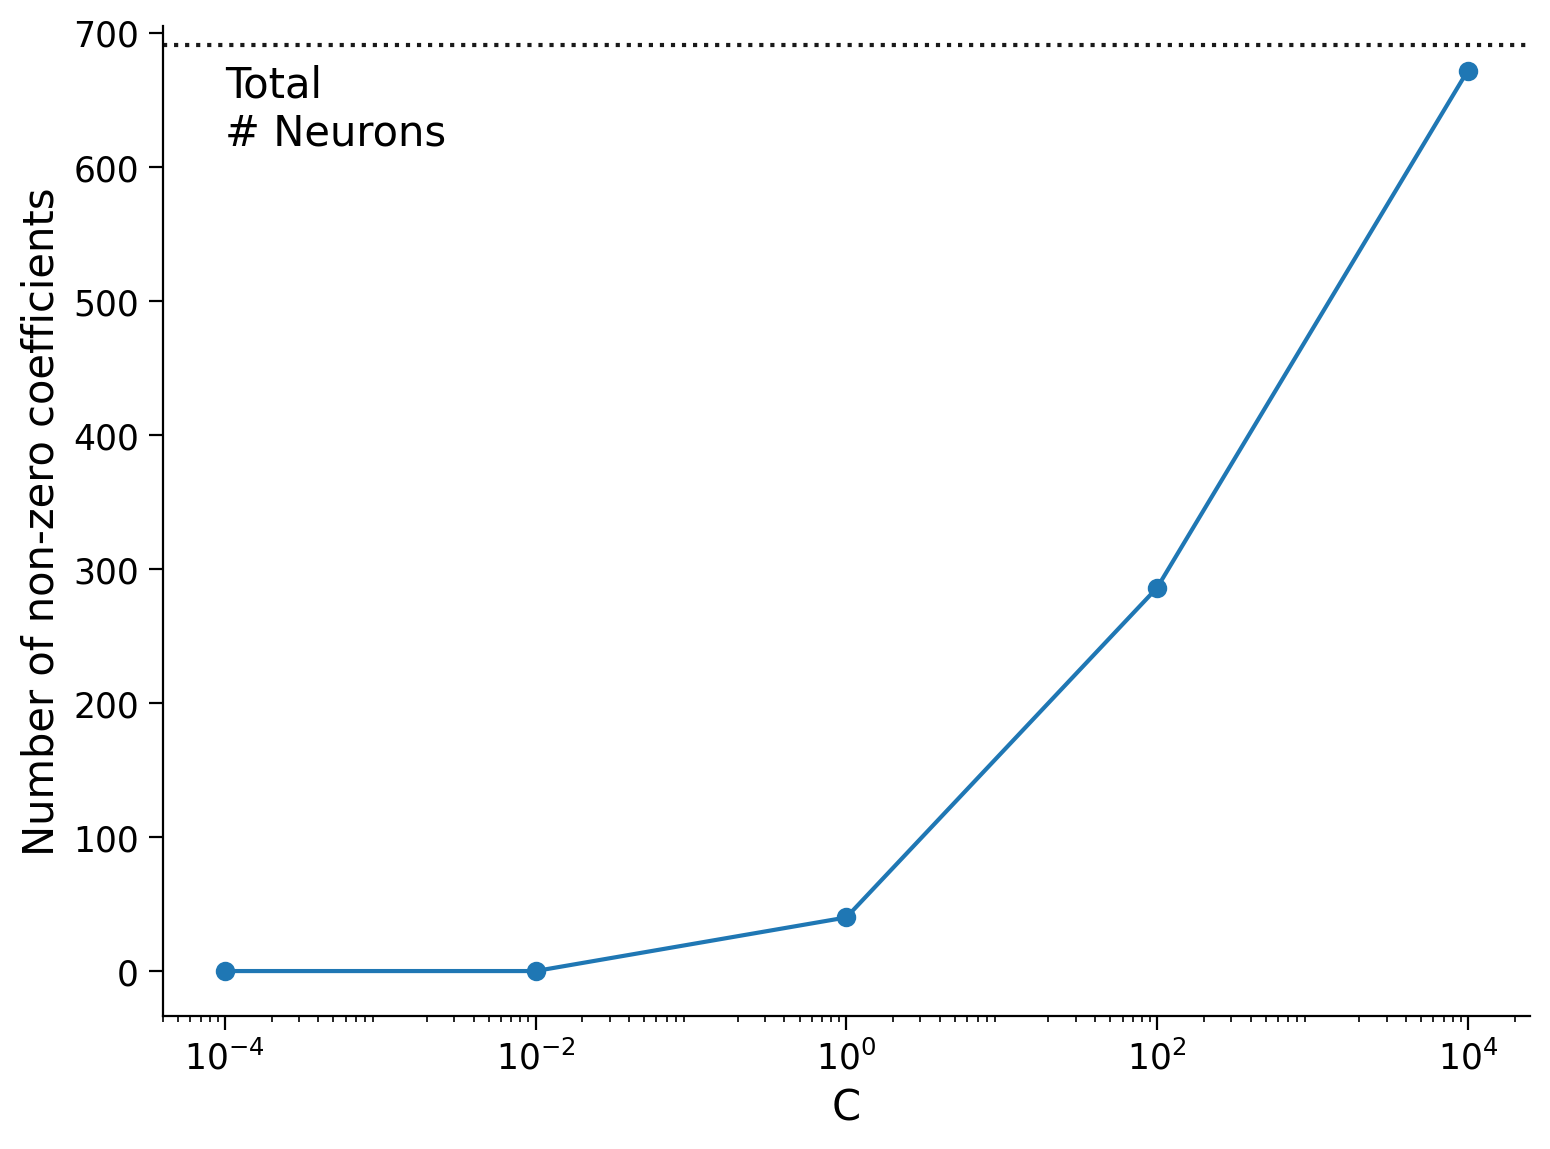

In [25]:
def count_non_zero_coefs(X, y, C_values):
  """Fit models with different L1 penalty values and count non-zero coefficients.

  Args:
    X (2D array): Data matrix
    y (1D array): Label vector
    C_values (1D array): List of hyperparameter values

  Returns:
    non_zero_coefs (list): number of coefficients in each model that are nonzero

  """
  #############################################################################
  # TODO Complete the function and remove the error
  #raise NotImplementedError("Implement the count_non_zero_coefs function")
  #############################################################################

  non_zero_coefs = []
  for C in C_values:

    # Initialize and fit the model
    # (Hint, you may need to set max_iter)
    model = LogisticRegression(penalty="l1", C=C, max_iter=5000, solver="saga")
    model.fit(X, y)


    # Get the coefs of the fit model (in sklearn, we can do this using model.coef_)
    coefs = model.coef_

    # Count the number of non-zero elements in coefs
    non_zero = np.count_nonzero(coefs)
    non_zero_coefs.append(non_zero)

  return non_zero_coefs


# Use log-spaced values for C
C_values = np.logspace(-4, 4, 5)

# Count non zero coefficients
non_zero_l1 = count_non_zero_coefs(X, y, C_values)

# Visualize
plot_non_zero_coefs(C_values, non_zero_l1, n_voxels=X.shape[1])

Smaller $C$ (bigger $\beta$) leads to sparser solutions.

**Link to neuroscience**: When is it OK to assume that the parameter vector is sparse? Whenever it is true that most features don't affect the outcome. One use-case might be decoding low-level visual features from whole-brain fMRI: we may expect only voxels in V1 and thalamus should be used in the prediction.

**WARNING**: be careful when interpreting $\theta$. Never interpret the nonzero coefficients as *evidence* that only those voxels/neurons/features carry information about the outcome. This is a product of our regularization scheme, and thus *our prior assumption that the solution is sparse*. Other regularization types or models may find very distributed relationships across the brain. Never use a model as evidence for a phenomena when that phenomena is encoded in the assumptions of the model.

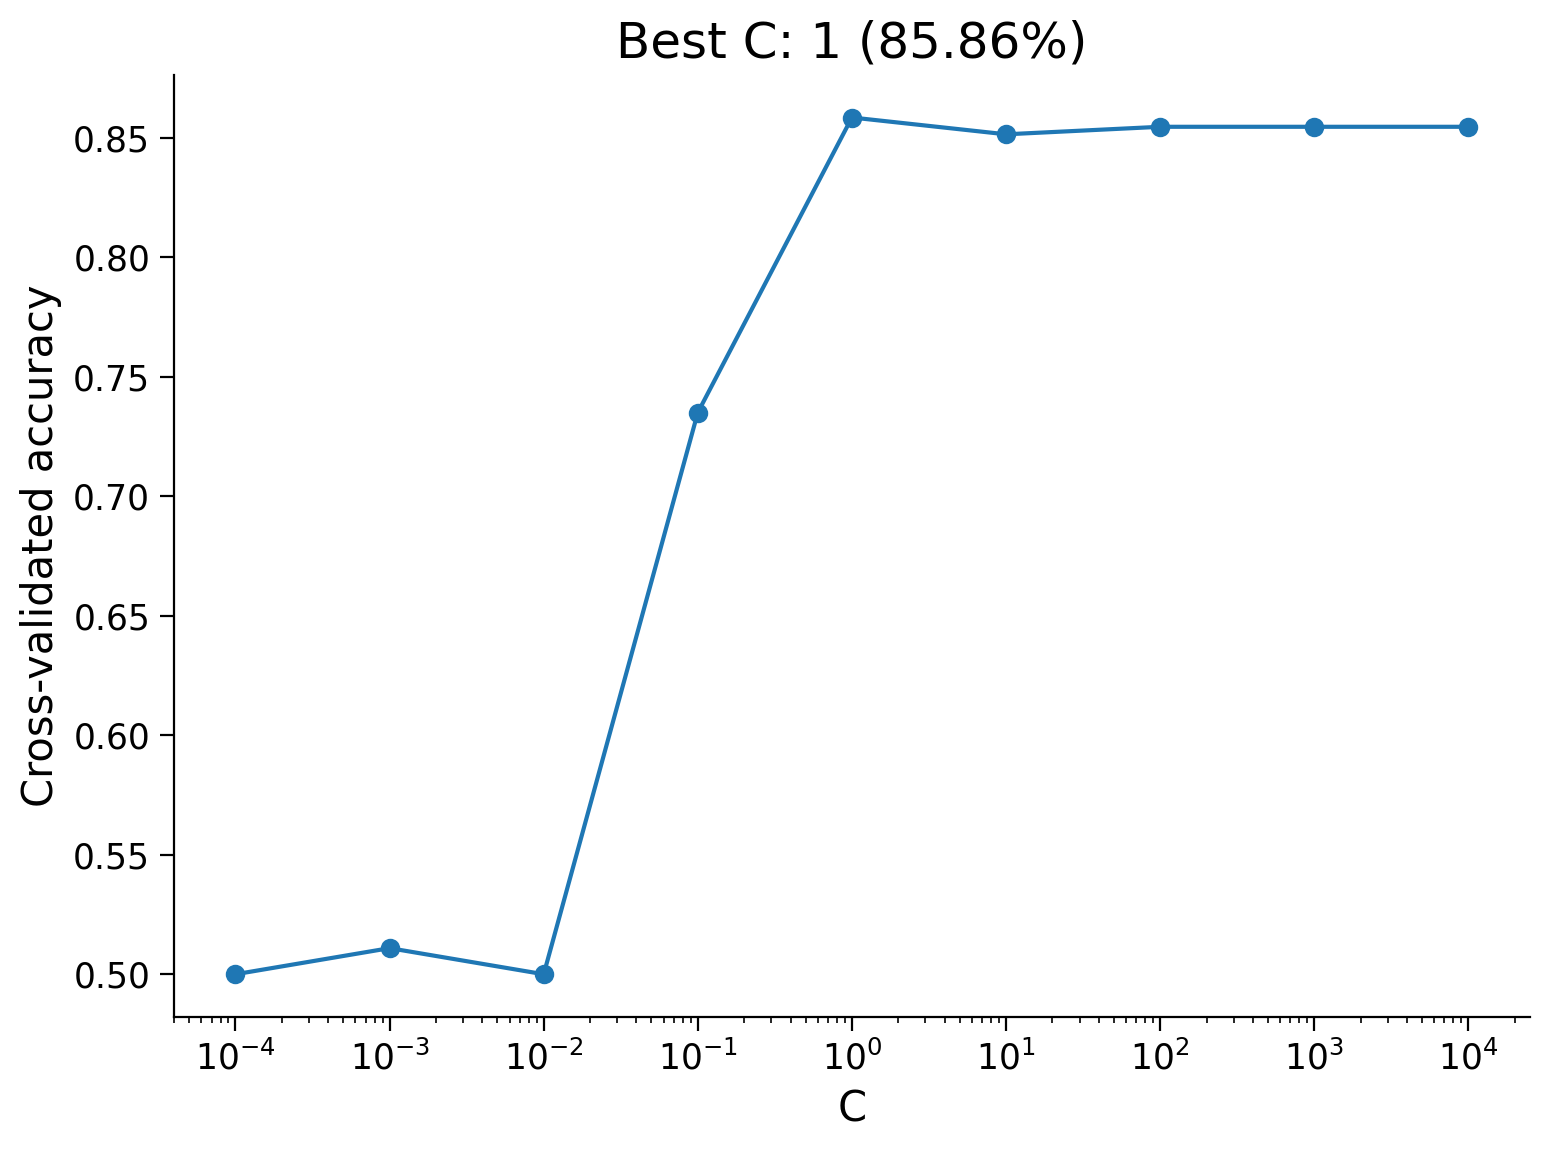

In [28]:
def model_selection(X, y, C_values):
  """Compute CV accuracy for each C value.

  Args:
    X (2D array): Data matrix
    y (1D array): Label vector
    C_values (1D array): Array of hyperparameter values

  Returns:
    accuracies (1D array): CV accuracy with each value of C

  """
  #############################################################################
  # TODO Complete the function and remove the error
  #raise NotImplementedError("Implement the model_selection function")
  #############################################################################

  accuracies = []
  for C in C_values:

    # Initialize and fit the model
    # (Hint, you may need to set max_iter)
    model = LogisticRegression(penalty="l1", C=C, max_iter=5000, solver="saga")
    model.fit(X, y)

    # Get the accuracy for each test split using cross-validation
    accs = cross_val_score(model, X, y, cv=8)

    # Store the average test accuracy for this value of C
    accuracies.append(accs.mean())

  return accuracies


# Use log-spaced values for C
C_values = np.logspace(-4, 4, 9)

# Compute accuracies
accuracies = model_selection(X, y, C_values)

# Visualize
plot_model_selection(C_values, accuracies)